## Ungraded Lab: MNIST Autoencoder

You will now work on an autoencoder that works on the [MNIST dataset](https://www.tensorflow.org/datasets/catalog/mnist). This will encode the inputs to lower resolution images. The decoder should then be able to generate the original input from this compressed representation.

In [3]:
!pip install tensorflow_datasets

## Imports

In [22]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense
from tensorflow.keras import Input, Model

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Prepare the Dataset

You will load the MNIST data from TFDS into train and test sets. Let's first define a preprocessing function for normalizing and flattening the images. Since we'll be training an autoencoder, this will return `image, image` because the input will also be the target or label while training.


In [9]:
def map_image(image, label):
  '''Normalizes and flattens the image. Returns image as input and label.'''
  image = tf.cast(image, dtype=tf.float32)
  image = image / 255.0
  image = tf.reshape(image, shape=(784,))

  return image, image

In [23]:
# Load and preprocess MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

BATCH_SIZE = 128
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, x_train))
train_dataset = train_dataset.shuffle(1024).batch(BATCH_SIZE).repeat()

test_dataset = tf.data.Dataset.from_tensor_slices((x_test, x_test))
test_dataset = test_dataset.batch(BATCH_SIZE)

print("Dataset prepared.")

Dataset prepared.


## Build the Model

You will now build a simple autoencoder to ingest the data. Like before, the encoder will compress the input and reconstructs it in the decoder output.

[![Deep.png](https://i.postimg.cc/02RbJk51/Deep.png)](https://postimg.cc/G9KcW1sX)

In [24]:
def deep_autoencoder(inputs):
  encoder=Dense(units=128,activation='relu')(inputs)
  encoder=Dense(units=64,activation='relu')(encoder)
  encoder=Dense(units=32,activation='relu')(encoder)
  decoder=Dense(units=64,activation='relu')(encoder)
  decoder=Dense(units=128,activation='relu')(decoder)
  decoder=Dense(units=784,activation='sigmoid')(decoder)
  return encoder, decoder

# Initialize models
encoderinput = Input(shape=(784,))
encoder_output, decoder_output = deep_autoencoder(encoderinput)
autoencoder_model = Model(inputs=encoderinput, outputs=decoder_output)
encoder_model = Model(inputs=encoderinput, outputs=encoder_output)

print("Model architecture defined.")

Model architecture defined.


## Compile the Model

You will setup the model for training. You can use binary crossentropy to measure the loss between pixel values that range from 0 (black) to 1 (white).

In [25]:
autoencoder_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
print("Model compiled.")

Model compiled.


## Train the Model

In [26]:
# Train the model
BATCH_SIZE = 128
train_steps = 60000 // BATCH_SIZE
simple_auto_history = autoencoder_model.fit(
    train_dataset,
    steps_per_epoch=train_steps,
    epochs=50
)

Epoch 1/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0100 - loss: 0.2107
Epoch 2/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0097 - loss: 0.1328
Epoch 3/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0095 - loss: 0.1190
Epoch 4/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0112 - loss: 0.1117
Epoch 5/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0116 - loss: 0.1071
Epoch 6/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0121 - loss: 0.1031
Epoch 7/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0120 - loss: 0.1002
Epoch 8/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0121 - loss: 0.0981
Epoch 9/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0121 - loss: 0.0961
Epoch 10/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0115 - loss: 0.0946
Epoch 11/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0129 - loss: 0.0933
Epoch 12/50
468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

## Display sample results

You can now visualize the results. The utility functions below will help in plotting the encoded and decoded values.

In [ ]:
def display_one_row(disp_images, offset, shape=(28, 28)):
  '''Display sample outputs in one row.'''
  for idx, test_image in enumerate(disp_images):
    plt.subplot(3, 10, offset + idx + 1)
    plt.xticks([])
    plt.yticks([])
    test_image = np.reshape(test_image, shape)
    plt.imshow(test_image, cmap='gray')


def display_results(disp_input_images, disp_encoded, disp_predicted, enc_shape=(8,4)):
  '''Displays the input, encoded, and decoded output values.'''
  plt.figure(figsize=(15, 5))
  display_one_row(disp_input_images, 0, shape=(28,28,))
  display_one_row(disp_encoded, 10, shape=enc_shape)
  display_one_row(disp_predicted, 20, shape=(28,28,))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


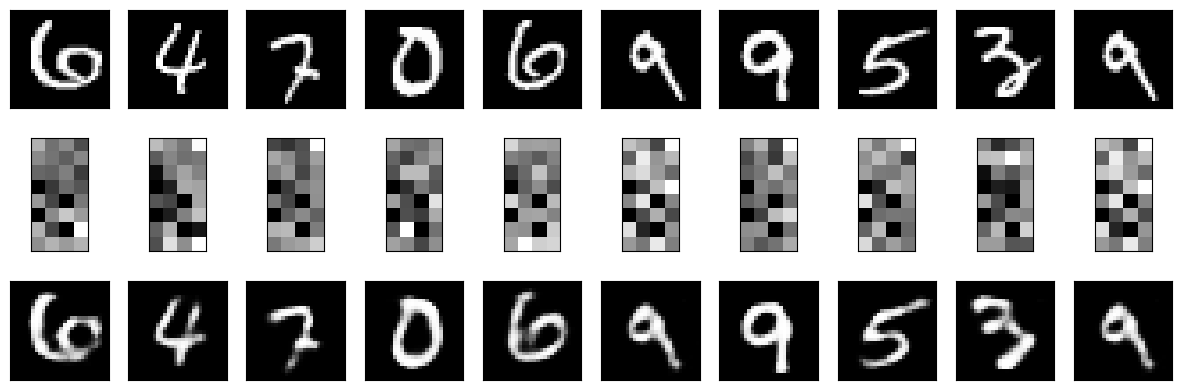

In [27]:
# Visualization using the processed x_test array directly
output_samples = x_test[:BATCH_SIZE]

# pick 10 random numbers to be used as indices
idxs = np.random.choice(len(output_samples), size=10)

# get the encoder output
encoded_predicted = encoder_model.predict(output_samples)

# get a prediction for the test batch
simple_predicted = autoencoder_model.predict(output_samples)

# display the 10 samples, encodings and decoded values!
display_results(output_samples[idxs], encoded_predicted[idxs], simple_predicted[idxs])

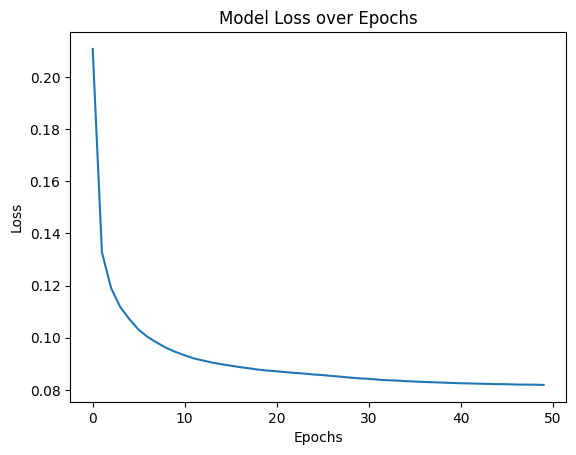

In [28]:
import matplotlib.pyplot as plt

# Plotting the training loss over epochs
plt.plot(simple_auto_history.history['loss'])
plt.title('Model Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()